# Đọc file 

In [2]:
import pandas as pd

# đọc file
df = pd.read_csv("/kaggle/input/datasets/thnhtrungnguynmif/vietnamhistory-nli/data_tk1_NLI_VietnamHistory.csv")

print(df.head())

                                            premise   \
0  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
1  Việt Nam Tuyên truyền Giải phóng quân là một t...   
2  ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...   
3  Dưới sự cai trị của Nhật, từ tháng 10 năm 1944...   
4  Cách mạng Tháng Tám, còn gọi là Tổng khởi nghĩ...   

                                       contradiction  \
0  Việt Nam Tuyên truyền Giải phóng quân được thà...   
1  Việt Nam Tuyên truyền Giải phóng quân không có...   
2  Chỉ thị được ban hành để kêu gọi hợp tác với q...   
3  Nạn đói năm 1945 không gây thiệt hại lớn về nh...   
4  Cách mạng Tháng Tám diễn ra hòa bình và không ...   

                                          entailment  \
0  Việt Nam Tuyên truyền Giải phóng quân được thà...   
1  Việt Nam Tuyên truyền Giải phóng quân là lực l...   
2  Tháng 3 năm 1945, Đảng Cộng sản Việt Nam đã kê...   
3  Trong thời gian Nhật chiếm đóng, Việt Nam xảy ...   
4  Cách mạng Tháng Tám năm 1945 đã lật đổ chín

In [4]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)


Index(['premise', 'contradiction', 'entailment', 'neutral'], dtype='object')


In [5]:


rows = []

for _, row in df.iterrows():

    premise = row["premise"]

    rows.append({
        "premise": premise,
        "hypothesis": row["contradiction"],
        "label": "contradiction"
    })

    rows.append({
        "premise": premise,
        "hypothesis": row["entailment"],
        "label": "entailment"
    })

    rows.append({
        "premise": premise,
        "hypothesis": row["neutral"],
        "label": "neutral"
    })

nli_df = pd.DataFrame(rows)

print(nli_df.head())

                                             premise  \
0  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
1  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
2  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
3  Việt Nam Tuyên truyền Giải phóng quân là một t...   
4  Việt Nam Tuyên truyền Giải phóng quân là một t...   

                                          hypothesis          label  
0  Việt Nam Tuyên truyền Giải phóng quân được thà...  contradiction  
1  Việt Nam Tuyên truyền Giải phóng quân được thà...     entailment  
2  Cuối năm 1944, phong trào vũ trang cách mạng ở...        neutral  
3  Việt Nam Tuyên truyền Giải phóng quân không có...  contradiction  
4  Việt Nam Tuyên truyền Giải phóng quân là lực l...     entailment  


In [6]:
label_map = {
    "contradiction": 0,
    "neutral": 1,
    "entailment": 2
}

nli_df["label"] = nli_df["label"].map(label_map)

In [7]:
print(nli_df.head())

                                             premise  \
0  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
1  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
2  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...   
3  Việt Nam Tuyên truyền Giải phóng quân là một t...   
4  Việt Nam Tuyên truyền Giải phóng quân là một t...   

                                          hypothesis  label  
0  Việt Nam Tuyên truyền Giải phóng quân được thà...      0  
1  Việt Nam Tuyên truyền Giải phóng quân được thà...      2  
2  Cuối năm 1944, phong trào vũ trang cách mạng ở...      1  
3  Việt Nam Tuyên truyền Giải phóng quân không có...      0  
4  Việt Nam Tuyên truyền Giải phóng quân là lực l...      2  


In [8]:
nli_df.to_csv("nli_dataset.csv", index=False)

# đọc lại file nli_dataset.csv rồi normalize nha cậu


# Normalize

In [170]:
import re

## khoảng cách

In [171]:
def normalize_space(text):
    text = str(text).strip()
    text = re.sub(r"\s+", " ", text)
    
    return text

In [172]:
text = "    Ngày 22 tháng 12     năm 1944, Võ Nguyên Giáp thành lập một trung đội 34 người mang tên Việt Nam Tuyên truyền Giải phóng quân "
print(f"Input:  {text}")
print(f"normalize:  {normalize_space(text)}")


Input:      Ngày 22 tháng 12     năm 1944, Võ Nguyên Giáp thành lập một trung đội 34 người mang tên Việt Nam Tuyên truyền Giải phóng quân 
normalize:  Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thành lập một trung đội 34 người mang tên Việt Nam Tuyên truyền Giải phóng quân


## Chuẩn hóa NGÀY / THÁNG / NĂM

In [173]:
def normalize_full_date(text):
    # 28/02/2025 | 28-02-2025
    text = re.sub(
        r"\b(\d{1,2})[\/\-](\d{1,2})[\/\-](\d{4})\b",
        lambda m: f"ngày_{int(m.group(1)):02d}_tháng_{int(m.group(2)):02d}_năm_{m.group(3)}",
        text
    )

    # ngày 28 tháng 2 năm 2025
    text = re.sub(
        r"\bngày\s*(\d{1,2})\s*tháng\s*(\d{1,2})\s*năm\s*(\d{4})\b",
        lambda m: f"ngày_{int(m.group(1)):02d}_tháng_{int(m.group(2)):02d}_năm_{m.group(3)}",
        text
    )
    return text

In [174]:
text = "22/12/1944 đến 22-12-1945"
print(f"Input:  {text}")
print(f"normalize:  {normalize_full_date(text)}")

Input:  22/12/1944 đến 22-12-1945
normalize:  ngày_22_tháng_12_năm_1944 đến ngày_22_tháng_12_năm_1945


## Chuẩn hóa NGÀY / THÁNG or THÁNG / NĂM 

In [175]:
def normalize_partial_date(text):

    # tháng 8 năm 1990
    text = re.sub(
        r"\btháng\s*(\d{1,2})\s*năm\s*(\d{4})\b",
        lambda m: f"tháng_{int(m.group(1)):02d}_năm_{m.group(2)}",
        text
    )

    # tháng 8/1990 | tháng 8-1990
    text = re.sub(
        r"\btháng\s*(\d{1,2})\s*[\/\-]\s*(\d{4})\b",
        lambda m: f"tháng_{int(m.group(1)):02d}_năm_{m.group(2)}",
        text
    )

    # ngày 17 tháng 10 (KHÔNG ăn vào dạng có năm)
    text = re.sub(
        r"\bngày\s*(\d{1,2})\s*tháng\s*(\d{1,2})\b(?!\s*năm)",
        lambda m: f"ngày_{int(m.group(1)):02d}_tháng_{int(m.group(2)):02d}",
        text
    )

    # 17/8 | 17-8 (đảm bảo không dính năm)
    text = re.sub(
        r"\b(\d{1,2})[\/\-](\d{1,2})\b(?![\/\-]\d{4})",
        lambda m: f"ngày_{int(m.group(1)):02d}_tháng_{int(m.group(2)):02d}",
        text
    )

    return text

In [176]:
text = "Sự kiện chính diễn ra ngày 17 tháng 10, giai đoạn chuẩn bị bắt đầu từ tháng 8 năm 1990, kế hoạch được phê duyệt vào tháng 3/2021 và hạn chót nộp hồ sơ là 5-9."
print(f"Input:  {text}")
print(f"normalize:  {normalize_partial_date(text)}")

Input:  Sự kiện chính diễn ra ngày 17 tháng 10, giai đoạn chuẩn bị bắt đầu từ tháng 8 năm 1990, kế hoạch được phê duyệt vào tháng 3/2021 và hạn chót nộp hồ sơ là 5-9.
normalize:  Sự kiện chính diễn ra ngày_17_tháng_10, giai đoạn chuẩn bị bắt đầu từ tháng_08_năm_1990, kế hoạch được phê duyệt vào tháng_03_năm_2021 và hạn chót nộp hồ sơ là ngày_05_tháng_09.


## Chuẩn hóa NĂM & GIAI ĐOẠN

In [177]:
def normalize_year(text):
    text = re.sub(r"\btừ\s+năm\s+(\d{4})\b", r"từ_năm_\1", text)
    text = re.sub(r"\bsau\s+năm\s+(\d{4})\b", r"sau_năm_\1", text)
    text = re.sub(r"\btrước\s+năm\s+(\d{4})\b", r"trước_năm_\1", text)
    text = re.sub(r"\bnăm\s+(\d{4})\b", r"năm_\1", text)

    # 1954–1975 | 1954-1975
    text = re.sub(
        r"\b(\d{4})\s*[–\-]\s*(\d{4})\b",
        r"giai_đoạn_\1_\2",
        text
    )
    return text

In [178]:
text = "Từ năm 1945, đất nước bước vào giai đoạn mới; sau năm 1954 tình hình có nhiều biến chuyển, trước năm 1975 xã hội còn nhiều khó khăn, năm 1986 đánh dấu công cuộc đổi mới, giai đoạn 1954–1975 là một thời kỳ lịch sử đặc biệt. "
print(f"Input:  {text}")
print(f"normalize:  {normalize_year(text)}")

Input:  Từ năm 1945, đất nước bước vào giai đoạn mới; sau năm 1954 tình hình có nhiều biến chuyển, trước năm 1975 xã hội còn nhiều khó khăn, năm 1986 đánh dấu công cuộc đổi mới, giai đoạn 1954–1975 là một thời kỳ lịch sử đặc biệt. 
normalize:  Từ năm_1945, đất nước bước vào giai đoạn mới; sau_năm_1954 tình hình có nhiều biến chuyển, trước_năm_1975 xã hội còn nhiều khó khăn, năm_1986 đánh dấu công cuộc đổi mới, giai đoạn giai_đoạn_1954_1975 là một thời kỳ lịch sử đặc biệt. 


## Xóa ký tự đặc biệt (bảo toàn pháp lý)

In [179]:
def remove_special_chars(text):
    # GIỮ _ . / - để không phá mốc thời gian & NĐ-CP
    text = re.sub(r"[^a-zA-Z0-9À-ỹà-ỹ\s\._\/\-]", "", text)
    return text

In [180]:
text = "Nghị định số 36/2025/NĐ-CP (ban hành ngày 14-03-2025), áp dụng từ_năm_2024 đến năm_2030!!! Liên hệ: email@test.com | hotline: 0909-123-456 @Bộ #Nội $Vụ% "
print(f"Input:  {text}")
print(f"normalize:  {remove_special_chars(text)}")

Input:  Nghị định số 36/2025/NĐ-CP (ban hành ngày 14-03-2025), áp dụng từ_năm_2024 đến năm_2030!!! Liên hệ: email@test.com | hotline: 0909-123-456 @Bộ #Nội $Vụ% 
normalize:  Nghị định số 36/2025/NĐ-CP ban hành ngày 14-03-2025 áp dụng từ_năm_2024 đến năm_2030 Liên hệ emailtest.com  hotline 0909-123-456 Bộ Nội Vụ 


## CHUẨN HÓA THỰC THỂ / VIẾT TẮT

In [181]:
NAME_MAP ={
    r"\bvõ nguyên giáp\b": "võ_nguyên_giáp",
    r"\bviệt nam\b": "việt_nam",
    r"\bthủ đô\b": "thủ_đô"
}
def normalize_name(text):
    for pattern, replacement in NAME_MAP.items():
        text = re.sub(pattern, replacement, text)
    return text

In [182]:


ENTITY_MAP = {
    # Quốc gia
    r"\bmĩ\b": "hoa kỳ",
    r"\bhoa kì\b": "hoa kỳ",
    r"\bhoa ky\b": "hoa kỳ",
    r"\bpháp\b": "thực dân pháp",

    # Tổ chức chính trị
    r"\bđcsvn\b": "đảng cộng sản việt nam",
    r"\btw\b": "trung ương",
    r"\btư\b": "trung ương",
    r"\bt\.w\b": "trung ương",
    r"\btnq\b": "nghị quyết",
    r"\bqđndvn\b": "quân đội nhân dân việt nam",

    # Văn bản hành chính
    r"\bqđ\b": "quyết định",
    r"\bnq\b": "nghị quyết",
    r"\bcp\b": "chính phủ"
}

def normalize_entities(text):
    text = text.lower()
    for pattern, replacement in ENTITY_MAP.items():
        text = re.sub(pattern, replacement, text)
    return text

In [183]:
text = "Mĩ và Hoa kì đã có phản ứng trước lập trường của Pháp. ĐCSVN chỉ đạo TW triển khai nghị quyết theo tinh thần T.W và tư, thực hiện tNQ của QĐNDVN. Theo QĐ của CP, NQ này được ban hành."
print(f"normalize:  {normalize_entities(text)}")

normalize:  hoa kỳ và hoa kỳ đã có phản ứng trước lập trường của thực dân pháp. đảng cộng sản việt nam chỉ đạo trung ương triển khai nghị quyết theo tinh thần trung ương và trung ương, thực hiện nghị quyết của quân đội nhân dân việt nam. theo quyết định của chính phủ, nghị quyết này được ban hành.


## CHUẨN HÓA SỐ LA MÃ

In [184]:
ROMAN_MAP = {
"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5,
"VI": 6, "VII": 7, "VIII": 8, "IX": 9,
"X": 10, "XI": 11, "XII": 12, "XIII": 13,
"XIV": 14, "XV": 15, "XVI": 16,
"XVII": 17, "XVIII": 18, "XIX": 19, "XX": 20
}


def normalize_roman_numerals(text):
    def replace(match):
        roman = match.group(0)
        return str(ROMAN_MAP.get(roman, roman))
    pattern = r"\b(" + "|".join(ROMAN_MAP.keys()) + r")\b"
    return re.sub(pattern, replace, text)

In [185]:
text = "Đại hội Đảng lần thứ XII diễn ra sau Đại hội XI và trước Đại hội XIII. Trong giai đoạn này, Quốc hội khóa XIV ban hành nhiều nghị quyết. "
print(f"normalize:  {normalize_roman_numerals(text)}")

normalize:  Đại hội Đảng lần thứ 12 diễn ra sau Đại hội 11 và trước Đại hội 13. Trong giai đoạn này, Quốc hội khóa 14 ban hành nhiều nghị quyết. 


## preprocess

In [186]:
def preprocess_text(text):
   
    text = normalize_space(text)
    # text = normalize_full_date(text)
    # text = normalize_partial_date(text)
    
    # text = normalize_year(text)
    text = normalize_roman_numerals(text)
    text = normalize_entities(text)
    text = normalize_name(text)
    text = remove_special_chars(text)
    return text

In [187]:
df["premise"] = df["premise"].apply(preprocess_text)
df["hypothesis"] = df["hypothesis"].apply(preprocess_text)

In [188]:
df

,premise,hypothesis,label
0,ngày 22 tháng 12 năm 1944 võ_nguyên_giáp thành...,việt_nam tuyên truyền giải phóng quân được thà...,entailment
1,việt_nam tuyên truyền giải phóng quân là một t...,việt_nam tuyên truyền giải phóng quân là lực l...,entailment
2,ngày 12 tháng 3 năm 1945 ban thường vụ trung ư...,tháng 3 năm 1945 đảng cộng sản việt_nam đã kêu...,entailment
3,dưới sự cai trị của nhật từ tháng 10 năm 1944 ...,trong thời gian nhật chiếm đóng việt_nam xảy r...,entailment
4,cách mạng tháng tám còn gọi là tổng khởi nghĩa...,cách mạng tháng tám năm 1945 đã lật đổ chính q...,entailment
...,...,...,...
1793,ngày 21tháng 8 năm 2002 thủ tướng chính phủ ký...,quyết định về quỹ bảo hiểm xã hội năm 2002 ảnh...,neutral
1794,ngày 1 tháng 9 năm 2002 khởi công xây dựng cầu...,công trình cầu bính sau khi khởi công năm 2002...,neutral
1795,ngày truyền thống của quân đội nhân dân là ngà...,ngày truyền thống của quân đội nhân dân góp ph...,neutral
1796,ngày truyền thống của công an nhân dân là ngày...,ngày truyền thống của công an nhân dân có ý ng...,neutral


## Trực quan hóa

In [189]:
 import matplotlib.pyplot as plt

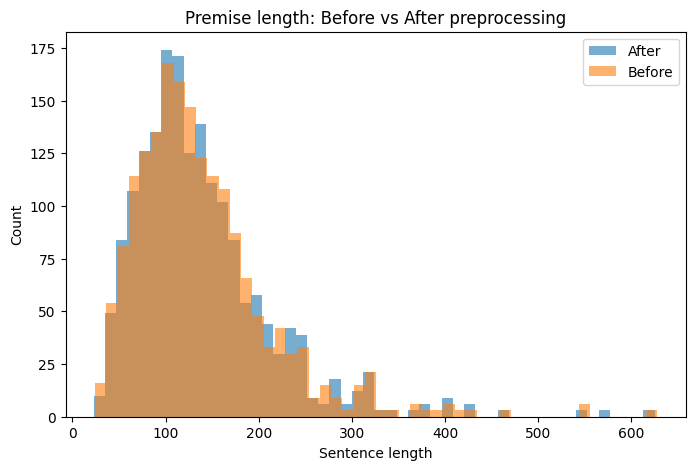

In [190]:
# phân bổ độ dài của câu premise trước và sau khi xữ lý dữ liệu
df["len_premise"] = df["premise"].astype(str).apply(len)
df_copy["len_premise"] = df_copy["premise"].astype(str).apply(len)

plt.figure(figsize=(8,5))
plt.hist(df["len_premise"], bins=50, alpha=0.6, label="After")
plt.hist(df_copy["len_premise"], bins=50, alpha=0.6, label="Before")
plt.xlabel("Sentence length")
plt.ylabel("Count")
plt.title("Premise length: Before vs After preprocessing")
plt.legend()
plt.show()

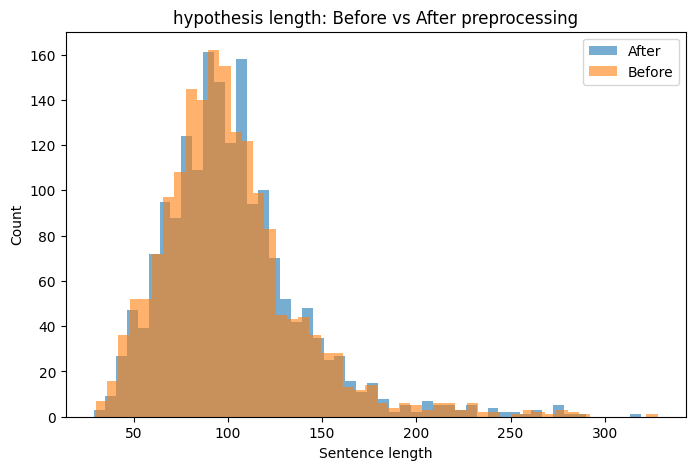

In [191]:
# phân bổ độ dài của câu hypothesis trước và sau khi xữ lý dữ liệu
df["len_hypothesis"] = df["hypothesis"].astype(str).apply(len)
df_copy["len_hypothesis"] = df_copy["hypothesis"].astype(str).apply(len)

plt.figure(figsize=(8,5))
plt.hist(df["len_hypothesis"], bins=50, alpha=0.6, label="After")
plt.hist(df_copy["len_hypothesis"], bins=50, alpha=0.6, label="Before")
plt.xlabel("Sentence length")
plt.ylabel("Count")
plt.title("hypothesis length: Before vs After preprocessing")
plt.legend()
plt.show()

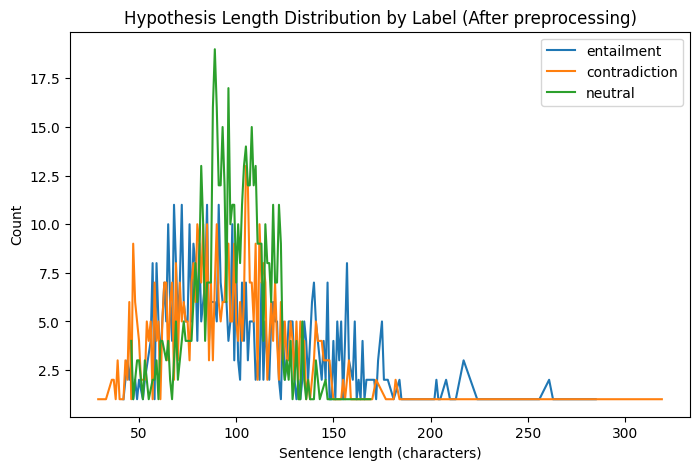

In [192]:

plt.figure(figsize=(8, 5))

for label in df["label"].unique():
    subset = df[df["label"] == label]

    # Đếm tần suất độ dài câu
    length_counts = subset["len_hypothesis"].value_counts().sort_index()

    # Vẽ biểu đồ đường
    plt.plot(
        length_counts.index,
        length_counts.values,
        label=label
    )

plt.xlabel("Sentence length (characters)")
plt.ylabel("Count")
plt.title("Hypothesis Length Distribution by Label (After preprocessing)")
plt.legend()
plt.show()


In [193]:
df.to_csv("all.csv", index=False, encoding="utf-8-sig")


In [194]:
df

,premise,hypothesis,label,len_premise,len_hypothesis
0,ngày 22 tháng 12 năm 1944 võ_nguyên_giáp thành...,việt_nam tuyên truyền giải phóng quân được thà...,entailment,120,72
1,việt_nam tuyên truyền giải phóng quân là một t...,việt_nam tuyên truyền giải phóng quân là lực l...,entailment,97,109
2,ngày 12 tháng 3 năm 1945 ban thường vụ trung ư...,tháng 3 năm 1945 đảng cộng sản việt_nam đã kêu...,entailment,183,88
3,dưới sự cai trị của nhật từ tháng 10 năm 1944 ...,trong thời gian nhật chiếm đóng việt_nam xảy r...,entailment,118,103
4,cách mạng tháng tám còn gọi là tổng khởi nghĩa...,cách mạng tháng tám năm 1945 đã lật đổ chính q...,entailment,247,82
...,...,...,...,...,...
1793,ngày 21tháng 8 năm 2002 thủ tướng chính phủ ký...,quyết định về quỹ bảo hiểm xã hội năm 2002 ảnh...,neutral,115,89
1794,ngày 1 tháng 9 năm 2002 khởi công xây dựng cầu...,công trình cầu bính sau khi khởi công năm 2002...,neutral,88,93
1795,ngày truyền thống của quân đội nhân dân là ngà...,ngày truyền thống của quân đội nhân dân góp ph...,neutral,94,97
1796,ngày truyền thống của công an nhân dân là ngày...,ngày truyền thống của công an nhân dân có ý ng...,neutral,107,99


# EMBEDDING

In [195]:
!pip install pyvi

In [196]:
from pyvi import ViTokenizer

df["premise_tok"] = df["premise"].apply(ViTokenizer.tokenize)
df["hypothesis_tok"] = df["hypothesis"].apply(ViTokenizer.tokenize)


In [197]:
print(df["premise_tok"][0])

ngày 22 tháng 12 năm 1944 võ_nguyên_giáp thành_lập một trung_đội 34 người mang tên việt_nam tuyên_truyền giải_phóng_quân


## Gom token

In [198]:
sentences = (
    df["premise_tok"].tolist() +
    df["hypothesis_tok"].tolist()
)

tokenized_sentences = [s.split() for s in sentences]


In [199]:
from collections import Counter

counter = Counter()
for sent in tokenized_sentences:
    counter.update(sent)


In [200]:

PAD = "<PAD>"
UNK = "<UNK>"

vocab = {PAD: 0, UNK: 1}

for word, freq in counter.items():
        vocab[word] = len(vocab)

inv_vocab = {i: w for w, i in vocab.items()}


In [201]:
print("Số lượng từ trong vocab:", len(vocab))
print("10 từ đầu tiên trong vocab:")
for i in range(10):
    print(i, "→", inv_vocab.get(i))


Số lượng từ trong vocab: 2916
10 từ đầu tiên trong vocab:
0 → <PAD>
1 → <UNK>
2 → ngày
3 → 22
4 → tháng
5 → 12
6 → năm
7 → 1944
8 → võ_nguyên_giáp
9 → thành_lập


## ONE-HOT ENCODING 

In [202]:
vocab_size = len(vocab)
print("Vocab size:", vocab_size)


Vocab size: 2916


In [203]:
import numpy as np

def one_hot_word(word, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    idx = vocab.get(word, vocab["<UNK>"])
    vec[idx] = 1
    return vec


In [204]:
word = "cách_mạng"
vec = one_hot_word(word, vocab)

print("Từ:", word)
print("Index:", vocab[word])
print("One-hot:", vec)
print("Vị trí = 1:", np.where(vec == 1)[0])


Từ: cách_mạng
Index: 66
One-hot: [0 0 0 ... 0 0 0]
Vị trí = 1: [66]


In [205]:
import torch
import torch.nn as nn


In [206]:
def build_skipgram_pairs(sentences, vocab, window=1):
    pairs = []
    for sent in sentences:
        for i, center in enumerate(sent):
            for j in range(max(0, i-window), min(len(sent), i+window+1)):
                if i != j:
                    pairs.append((center, sent[j]))
    return pairs


pairs = build_skipgram_pairs(tokenized_sentences, vocab)


In [207]:
print("Tổng số pairs:", len(pairs))
print("5 pairs đầu:")
for p in pairs[:25]:
    print(p)


Tổng số pairs: 141230
5 pairs đầu:
('ngày', '22')
('22', 'ngày')
('22', 'tháng')
('tháng', '22')
('tháng', '12')
('12', 'tháng')
('12', 'năm')
('năm', '12')
('năm', '1944')
('1944', 'năm')
('1944', 'võ_nguyên_giáp')
('võ_nguyên_giáp', '1944')
('võ_nguyên_giáp', 'thành_lập')
('thành_lập', 'võ_nguyên_giáp')
('thành_lập', 'một')
('một', 'thành_lập')
('một', 'trung_đội')
('trung_đội', 'một')
('trung_đội', '34')
('34', 'trung_đội')
('34', 'người')
('người', '34')
('người', 'mang')
('mang', 'người')
('mang', 'tên')


In [208]:
import torch

X = torch.tensor([vocab[c] for c, _ in pairs], dtype=torch.long)
Y = torch.tensor([vocab[t] for _, t in pairs], dtype=torch.long)

print("X:", X[:5])
print("Y:", Y[:5])


X: tensor([2, 3, 3, 4, 4])
Y: tensor([3, 2, 4, 3, 5])


In [209]:
import torch.nn as nn

class SkipGramNN(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):
        emb = self.embedding(x)      # (batch, embed_dim)
        out = self.linear(emb)       # (batch, vocab_size)
        return out


In [210]:
V = len(vocab)

In [211]:
embed_dim = 3000

model = SkipGramNN(V, embed_dim)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [212]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X = X.to(device)
Y = Y.to(device)
model.to(device)


SkipGramNN(
  (embedding): Embedding(2916, 3000)
  (linear): Linear(in_features=3000, out_features=2916, bias=True)
)

In [213]:
for epoch in range(300):
    optimizer.zero_grad()

    logits = model(X)      # forward
    loss = criterion(logits, Y)

    loss.backward()        # backprop
    optimizer.step()

    
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 8.1538
Epoch 1, Loss: 10.3154
Epoch 2, Loss: 13.7562
Epoch 3, Loss: 15.3673
Epoch 4, Loss: 16.2416
Epoch 5, Loss: 16.4247
Epoch 6, Loss: 16.4602
Epoch 7, Loss: 16.4129
Epoch 8, Loss: 16.3018
Epoch 9, Loss: 16.1536
Epoch 10, Loss: 15.8453
Epoch 11, Loss: 15.5540
Epoch 12, Loss: 15.3827
Epoch 13, Loss: 15.1404
Epoch 14, Loss: 14.7633
Epoch 15, Loss: 14.4839
Epoch 16, Loss: 14.2026
Epoch 17, Loss: 13.8270
Epoch 18, Loss: 13.4781
Epoch 19, Loss: 13.1288
Epoch 20, Loss: 12.7853
Epoch 21, Loss: 12.3906
Epoch 22, Loss: 12.0394
Epoch 23, Loss: 11.7035
Epoch 24, Loss: 11.2456
Epoch 25, Loss: 10.8514
Epoch 26, Loss: 10.5450
Epoch 27, Loss: 10.3052
Epoch 28, Loss: 10.0458
Epoch 29, Loss: 9.7944
Epoch 30, Loss: 9.4948
Epoch 31, Loss: 9.2321
Epoch 32, Loss: 8.9293
Epoch 33, Loss: 8.6571
Epoch 34, Loss: 8.4533
Epoch 35, Loss: 8.1881
Epoch 36, Loss: 7.9539
Epoch 37, Loss: 7.8099
Epoch 38, Loss: 7.5571
Epoch 39, Loss: 7.3347
Epoch 40, Loss: 7.1098
Epoch 41, Loss: 6.9141
Epoch 42, Loss: 

In [214]:
embeddings = model.embedding.weight.detach()

print("Embedding shape:", embeddings.shape)


Embedding shape: torch.Size([2916, 3000])


In [216]:
import torch.nn.functional as F

def most_similar(word, top_k=10):
    if word not in vocab:
        print("Word not in vocab")
        return

    w_id = vocab[word]
    w_vec = embeddings[w_id]

    sims = F.cosine_similarity(w_vec.unsqueeze(0), embeddings)
    top_ids = torch.topk(sims, top_k + 1).indices.tolist()

    print(f"Top {top_k} từ gần '{word}':")
    for i in top_ids:
        if i != w_id:
            print(inv_vocab[i], float(sims[i]))

most_similar("võ_nguyên_giáp")


Top 10 từ gần 'võ_nguyên_giáp':
bẫy 0.06715186685323715
lật_ngược 0.06154128164052963
trạng_thái 0.06020016968250275
khôi_phục 0.06016508489847183
đô_la 0.058760084211826324
tổng_thống 0.057706087827682495
lên 0.05481891334056854
6e 0.051852963864803314
chú_ý 0.05175726115703583
pháo_hạm 0.050946399569511414
